Análisis de datos de ventas

Beatriz Abigail Trujillo Martínez

Ventas

In [49]:
import pandas as pd

# Base de datos
datos = pd.read_csv('sales_data_2023.csv')

# Para visualizar las primeras 5 filas 
datos.head()

,Sale_ID,Customer_ID,Sale_Amount,Sale_Date,Geography
0,1,38,31.11,2023-05-03,West
1,2,18,191.54,2023-03-06,South
2,3,197,283.74,2023-06-23,East
3,4,185,367.13,2023-02-09,South
4,5,171,188.52,2023-12-25,South


In [12]:
# Tipo de datos de la base de datos junto con nulos
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sale_ID      1000 non-null   int64  
 1   Customer_ID  1000 non-null   int64  
 2   Sale_Amount  1000 non-null   float64
 3   Sale_Date    1000 non-null   object 
 4   Geography    1000 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 39.2+ KB


La base de datos no contiene nulos, esto se puede visualizar en la tabla anterior donde se encuentra la columna Non-Null Count, el cual nos menciona que no contiene nulos en los 1000 registros que esta conformada la base de datos.
Por otro lado, el tipo de dato de sale_date es incorrecto dado que son fechas se debe de manejar datetime64.

In [13]:
# Tipo de datos 
datos.dtypes

Sale_ID          int64
Customer_ID      int64
Sale_Amount    float64
Sale_Date       object
Geography       object
dtype: object

In [14]:
# Datos nulos
datos.isnull().sum()

Sale_ID        0
Customer_ID    0
Sale_Amount    0
Sale_Date      0
Geography      0
dtype: int64

In [15]:
# Cambio de tipo de dato
# Dato que el campo de sale_date se encuentra incorrecto el tipo de dato se decide cambiar de formato
datos['Sale_Date'] = pd.to_datetime(datos['Sale_Date'])

In [16]:
#Cambio de tipo de dato
#Geographic cambia a categoria solo porque contiene pocas opciones
datos['Geography'].astype('category')

0       West
1      South
2       East
3      South
4      South
       ...  
995     East
996     West
997     West
998    South
999    South
Name: Geography, Length: 1000, dtype: category
Categories (4, object): ['East', 'North', 'South', 'West']

In [17]:
#Revisar si los campos se convirtieron en el tipo de campo deseado
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Sale_ID      1000 non-null   int64         
 1   Customer_ID  1000 non-null   int64         
 2   Sale_Amount  1000 non-null   float64       
 3   Sale_Date    1000 non-null   datetime64[ns]
 4   Geography    1000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 39.2+ KB


En la tabla anterior se puede observar que en la columna dtype que es el tipo de dato, las variables de sale_date y geography estan ahora ya correctas con el tipo de campo correspondiente

In [18]:
# Cuenta cuántas filas están repetidas completamente
datos.duplicated().sum()

np.int64(0)

Resultados

Ventas por región

In [22]:
#Ventas agrupadas por región
import pandas as pd
import matplotlib.pyplot as plt

ventas_region = datos.groupby('Geography')['Sale_Amount'].sum()

# Mostrar la tabla resultante
print(ventas_region)

Geography
East     59257.68
North    64482.18
South    60564.90
West     69228.16
Name: Sale_Amount, dtype: float64


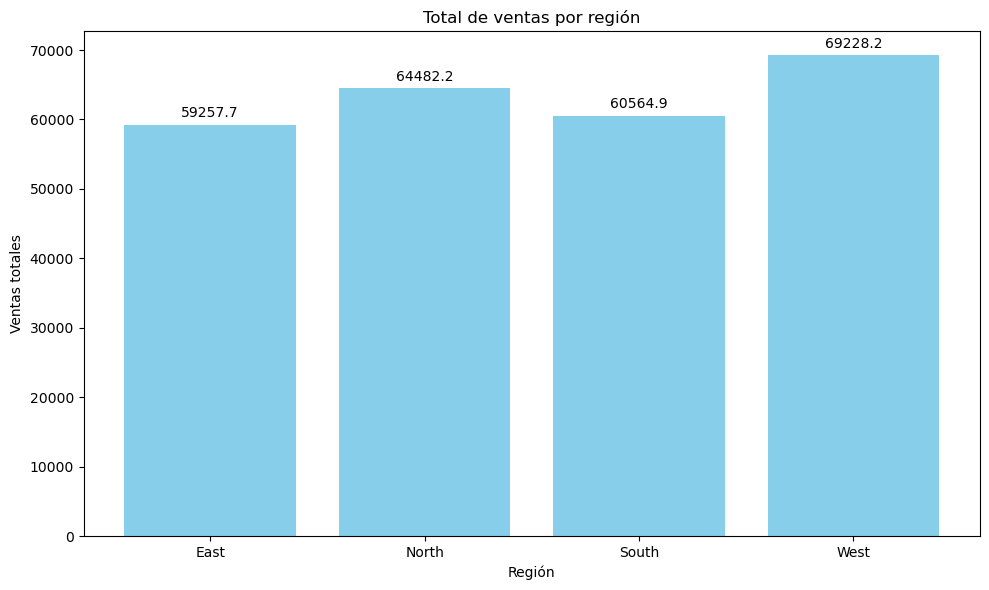

In [29]:
#Grafico
# Lienzo y tamaño
fig, ax = plt.subplots(figsize=(10, 6))
# Datos
barras = ax.bar(ventas_region.index, ventas_region.values, color='skyblue')

# 4. Agregar etiquetas a las barras
ax.bar_label(barras, padding=3) # padding es el espacio entre la barra y el número

plt.title('Total de ventas por región') # Titulo del gráfico
plt.xlabel('Región') # Titulo del eje x
plt.ylabel('Ventas totales') # Titulo del eje y
plt.xticks(rotation=360) 
plt.tight_layout()

plt.show()

En el gráfico anterior se muestra que la región con mayor número de ventas es la Oeste con 69 228.2, seguido del Norte, como se puede apreciar la mayoria se encuentra en un rango de 59 000 hasta 70 000. 


Ventas por mes

In [45]:
# Ventas por fecha
# 2. Ordenar por fecha
datos = datos.sort_values('Sale_Date')
# 3. Agrupar por fecha y sumar ventas
ventas_mensuales = datos.groupby(datos['Sale_Date'].dt.to_period('M')) ['Sale_Amount'].sum()

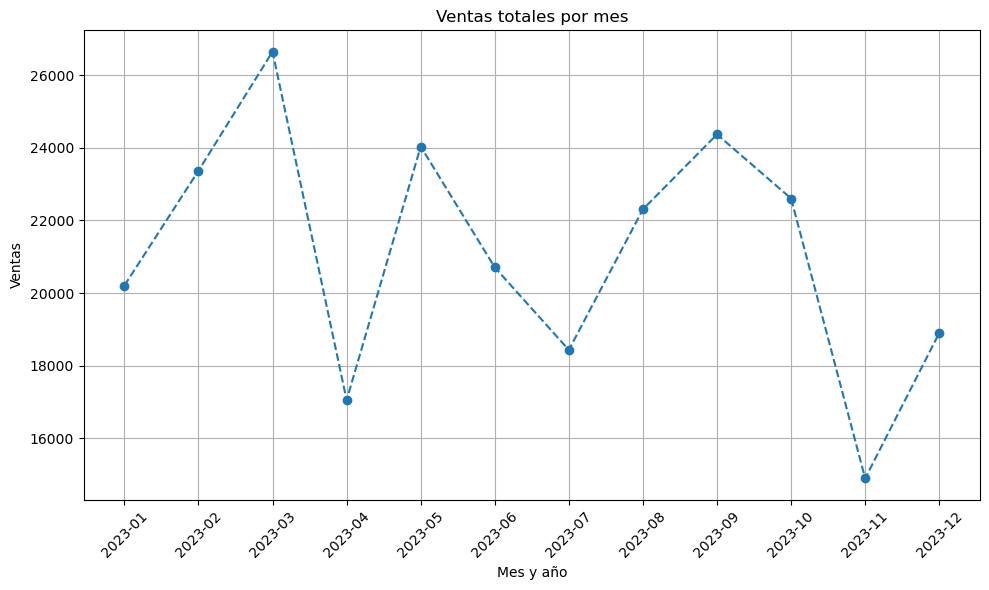

In [48]:
#Gráfico
# Definir el lienzo
fig, ax = plt.subplots(figsize=(10, 6))

# Dibujar la línea
ax.plot(ventas_mensuales.index.astype(str), ventas_mensuales.values, marker='o', linestyle='--')

# Configurar títulos y etiquetas
plt.title('Ventas totales por mes')
plt.xlabel('Mes y año')
plt.ylabel('Ventas') 
plt.grid(True)

# Rotar las fechas del eje X para que no se amontonen
plt.xticks(rotation=45)

# Ajustar márgenes para que no se corte nada
plt.tight_layout()

plt.show()

En el gráfico anterior se muestran las ventas totales por mes, el cual se aprecia que el mes de marzo en el año 2023 fue uno de los meses con mayor ventas, seguido de septiembre, sin embargo tuvo un decremento en los meses de abril y noviembre del mismo año. 

Ventas de región por mes

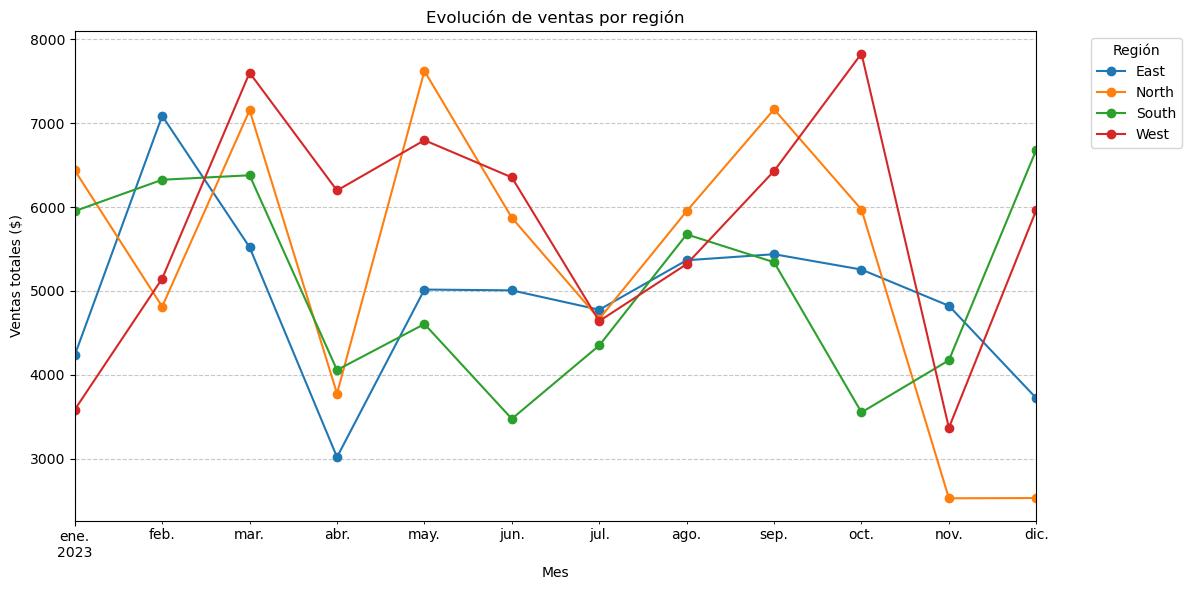

In [ ]:
# 1. Agrupar por mes y región
ventas_mes_region = datos.groupby([datos['Sale_Date'].dt.to_period('M'), 'Geography'])['Sale_Amount'].sum().unstack()

# 2. Graficar
fig, ax = plt.subplots(figsize=(12, 6))
# Línea por cada columna (región)
ventas_mes_region.plot(kind='line', marker='o', ax=ax)

# 
ax.set_title('Evolución de ventas por región')
ax.set_ylabel('Ventas totales')
ax.set_xlabel('Mes')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(title='Región', bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()
plt.show()

En el gráfico de evolución de ventas por región en el año 2023 se visualiza que la región del Oeste (rojo) y Norte (naranja) son de las regiones que destacaron, sin embargo, la región Norte presentó una alta volatilidad, registrando periodos de ventas significativas seguidos de un descenso drástico en noviembre, periodo tras el cual mantuvo un bajo desempeño hasta finalizar el año. 
De la misma manera, la región East (azul) parece ser la más estable; aunque no tiene los picos más altos, mantiene un comportamiento más predecible en comparación con las otras. 
Asimismo, el mes de julio parece ser un punto de convergencia donde casi todas las regiones tienen un rendimiento similar (cerca de los 4,500 - 5,000 ), lo cual podría ser un mes bajo general para toda la organización.